In [55]:
import pandas as pd

In [56]:
import matplotlib.pyplot as plt

In [57]:
import seaborn as sns

In [58]:
%matplotlib inline

In [59]:
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression

In [60]:
from sklearn.ensemble import RandomForestRegressor

In [61]:
from sklearn.model_selection import train_test_split

In [62]:
import numpy as np

In [63]:
df = pd.read_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/4. Scaling/Scaling(One-Hot).csv")

In [64]:
df.head()

,Game Title,Critic Score,Sales,North American Sales,Japanese Sales,EU Sales,Other Sales,Release Year,Genre_Action-Adventure,Genre_Adventure,...,Developer_Vicarious Visions,Developer_Visual Concepts,Decade,NA Share,EU Share,JP Share,Other Share,Is Recent,Game Quality,Game Quality Encoded
0,Grand Theft Auto V,0.933333,1.000000,0.652664,0.464789,1.000000,1.000000,2013,0,0,...,0,0,2010,0.313330,0.484506,0.048697,0.153468,0,High,2
1,Grand Theft Auto V,0.966667,0.953740,0.620902,0.281690,0.985787,0.967949,2014,0,0,...,0,0,2010,0.312532,0.500774,0.030944,0.155750,0,High,2
2,Grand Theft Auto: Vice City,0.955556,0.794291,0.861680,0.220657,0.557360,0.570513,2002,0,0,...,0,0,2000,0.520743,0.339938,0.029102,0.110217,0,High,2
3,Grand Theft Auto V,0.677988,0.780512,0.928279,0.028169,0.541117,0.455128,2013,0,0,...,0,0,2010,0.570888,0.335854,0.003781,0.089477,0,High,2
4,Call of Duty: Black Ops 3,0.788889,0.742126,0.633197,0.192488,0.614213,0.782051,2015,0,0,...,0,0,2010,0.409543,0.400928,0.027170,0.161696,1,High,2


In [65]:
df.dtypes # check data types

Game Title               object
Critic Score            float64
Sales                   float64
North American Sales    float64
Japanese Sales          float64
                         ...   
JP Share                float64
Other Share             float64
Is Recent                 int64
Game Quality             object
Game Quality Encoded      int64
Length: 133, dtype: object

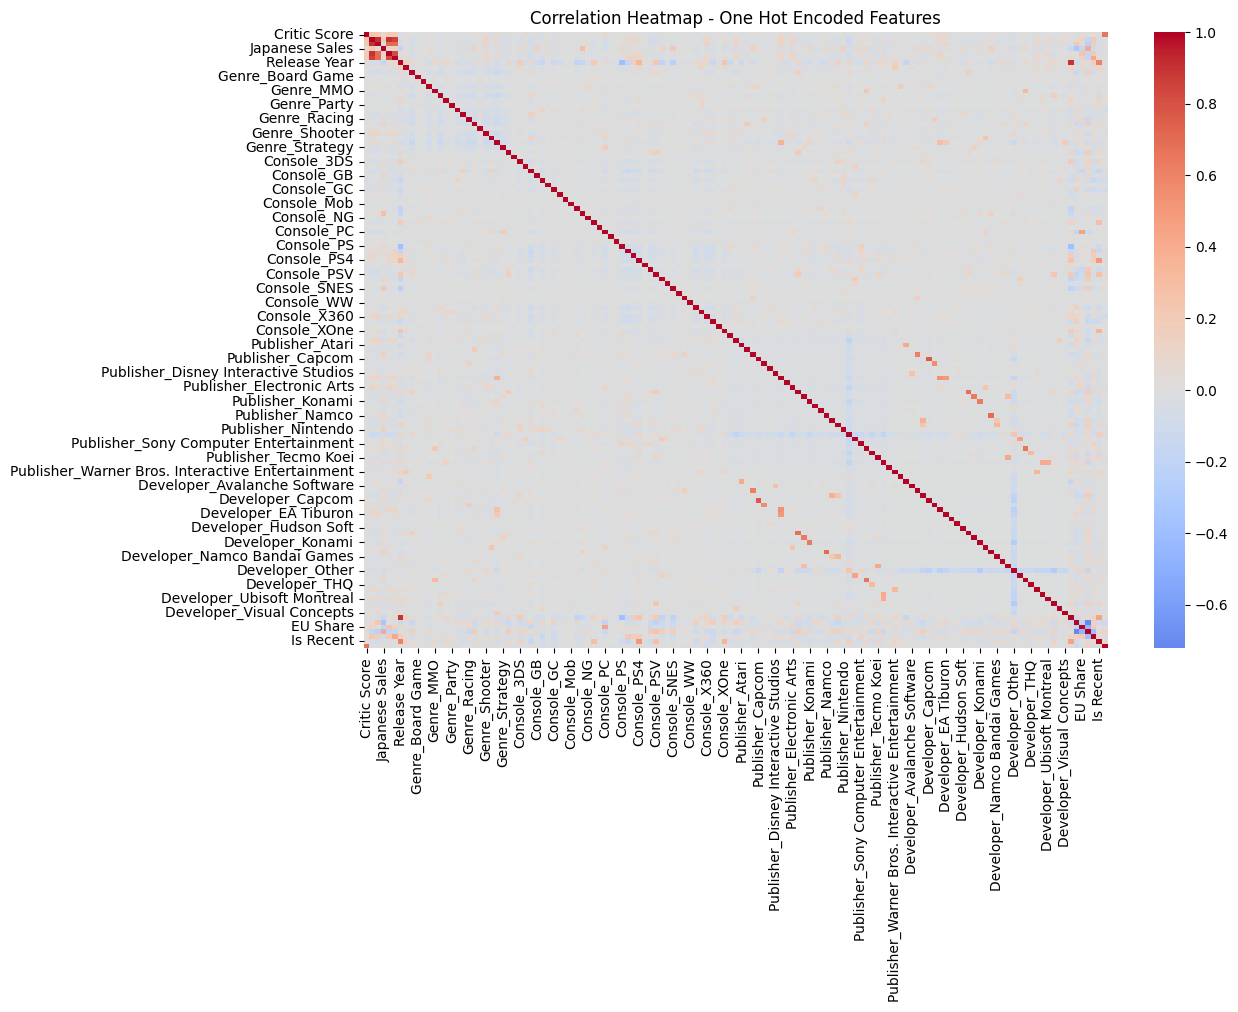

In [66]:
# Correlation Heatmap (EDA step)

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - One Hot Encoded Features")
plt.show()

In [67]:
# Variance Threshold

X = df.drop(columns=["Sales"]).select_dtypes(include="number").copy()
y = df["Sales"].astype(float)

# make it finite + numeric
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(0)

vt = VarianceThreshold(threshold=0.001)
X_vt = X.loc[:, vt.fit(X).get_support()]

print("Original features:", X.shape[1])
print("After VarianceThreshold:", X_vt.shape[1])

Original features: 130
After VarianceThreshold: 113


Top MI features:
 Other Share             1.913037
NA Share                1.533813
EU Share                1.394107
North American Sales    1.146277
Other Sales             0.758360
EU Sales                0.703330
Japanese Sales          0.573307
JP Share                0.293604
Critic Score            0.085683
Release Year            0.053225
Decade                  0.044362
Publisher_Other         0.042694
Console_PC              0.022810
Is Recent               0.019728
Developer_Unknown       0.015500
dtype: float64


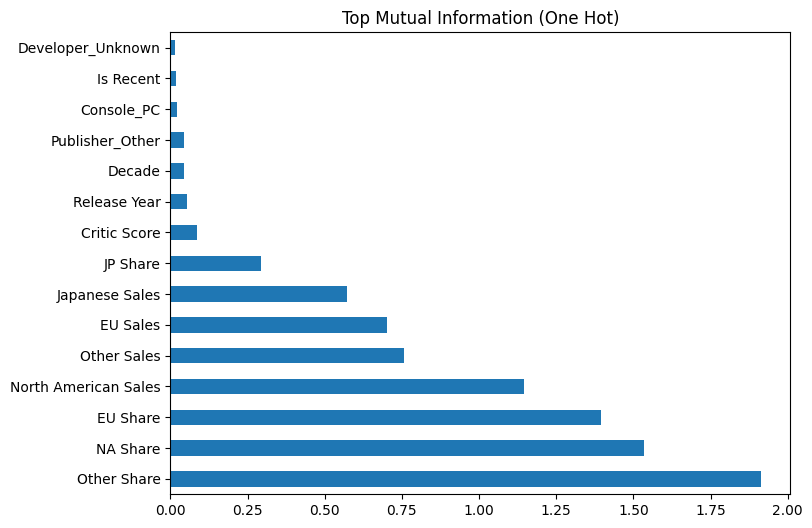

In [68]:
# Mutual Information

mi = mutual_info_regression(X_vt.fillna(0), y)
mi_scores = pd.Series(mi, index=X_vt.columns).sort_values(ascending=False)

print("Top MI features:\n", mi_scores.head(15))

mi_scores.head(15).plot(kind="barh", figsize=(8,6), title="Top Mutual Information (One Hot)")
plt.show()

Top RF features:
 EU Sales                0.494218
North American Sales    0.365052
Other Sales             0.108980
Japanese Sales          0.014321
NA Share                0.006935
EU Share                0.003735
Other Share             0.001995
JP Share                0.001321
Critic Score            0.000788
Release Year            0.000788
Genre_Shooter           0.000210
Publisher_Other         0.000176
Console_X360            0.000164
Is Recent               0.000151
Console_PS3             0.000096
dtype: float64


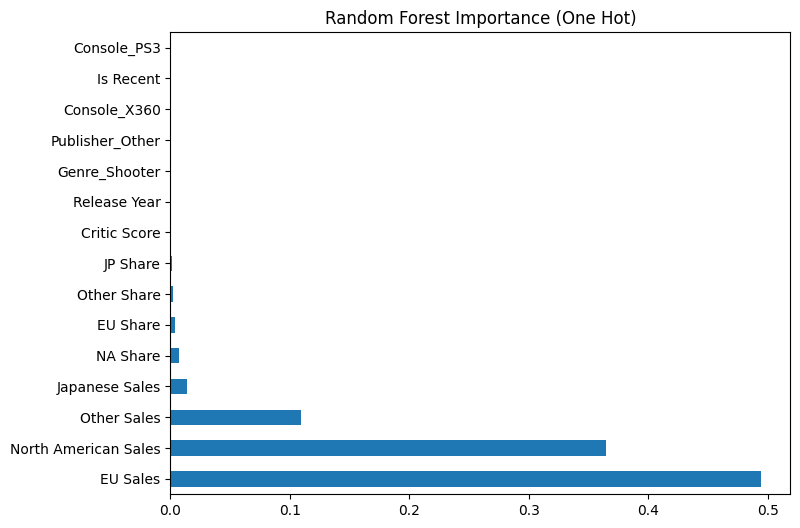

In [69]:
# Random Forest Importance

X_train, X_test, y_train, y_test = train_test_split(X_vt.fillna(0), y, test_size=0.2, random_state=42)
rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

rf_importances = pd.Series(rf.feature_importances_, index=X_vt.columns).sort_values(ascending=False)

print("Top RF features:\n", rf_importances.head(15))

rf_importances.head(15).plot(kind="barh", figsize=(8,6), title="Random Forest Importance (One Hot)")
plt.show()

In [ ]:
df.to_csv("/Users/senuja/Jupyter Notebook/Video_Game_Sales_Predictor/data/external/5. Feature Selection/Feature Selection(1-hot).csv", index=False)